In [46]:
# Basic usage sketch
from kan import KAN, create_dataset
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
# import scaler
from sklearn.preprocessing import StandardScaler
import sympy
import numpy as np

# create a KAN: 2D inputs, 1D output, and 5 hidden neurons. cubic spline (k=3), 5 grid intervals (grid=5).
model = KAN(width=[4,2,1,1], grid=3, k=3, seed=1, device='cpu')
f = lambda x: torch.exp((torch.sin(torch.pi*(x[:,[0]]**2+x[:,[1]]**2))+torch.sin(torch.pi*(x[:,[2]]**2+x[:,[3]]**2)))/2)
dataset = create_dataset(f, n_var=4, train_num=3000, device='cpu')

# train the model
model.fit(dataset, opt="LBFGS", steps=50, lamb=0.002, lamb_entropy=2.)


checkpoint directory created: ./model
saving model version 0.0


description:   0%|                                                           | 0/50 [00:00<?, ?it/s]

| train_loss: 3.03e-01 | test_loss: 3.08e-01 | reg: 1.01e+01 | : 100%|█| 50/50 [00:23<00:00,  2.14it

saving model version 0.1


{'train_loss': [array(0.5177121, dtype=float32),
  array(0.3821296, dtype=float32),
  array(0.34308997, dtype=float32),
  array(0.3281101, dtype=float32),
  array(0.32042906, dtype=float32),
  array(0.3171305, dtype=float32),
  array(0.31336647, dtype=float32),
  array(0.3102294, dtype=float32),
  array(0.30866724, dtype=float32),
  array(0.307904, dtype=float32),
  array(0.30860105, dtype=float32),
  array(0.3081498, dtype=float32),
  array(0.3077637, dtype=float32),
  array(0.30726013, dtype=float32),
  array(0.306534, dtype=float32),
  array(0.30729997, dtype=float32),
  array(0.3062952, dtype=float32),
  array(0.3060046, dtype=float32),
  array(0.3054474, dtype=float32),
  array(0.30507353, dtype=float32),
  array(0.30619735, dtype=float32),
  array(0.30555394, dtype=float32),
  array(0.3051471, dtype=float32),
  array(0.30498838, dtype=float32),
  array(0.30462167, dtype=float32),
  array(0.30600986, dtype=float32),
  array(0.30468804, dtype=float32),
  array(0.3044027, dtype=floa

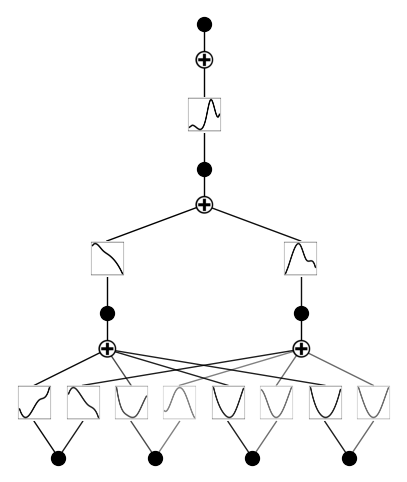

In [47]:
model.plot()

In [48]:
model = model.prune(edge_th=1e-2)

saving model version 0.2


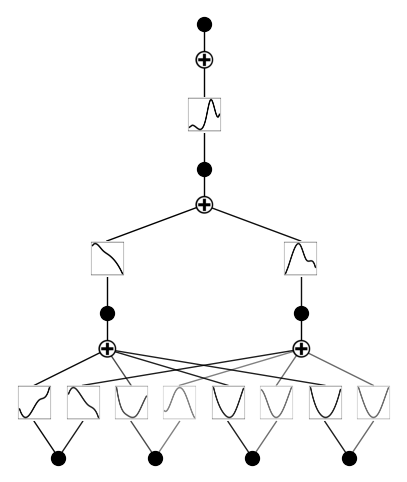

In [49]:
model.plot()

In [50]:
model.auto_symbolic()

fixing (0,0,0) with 0, r2=0.0, c=0
fixing (0,0,1) with 0, r2=0.0, c=0
fixing (0,1,0) with 0, r2=0.0, c=0
fixing (0,1,1) with 0, r2=0.0, c=0
fixing (0,2,0) with cos, r2=0.9975945949554443, c=2
fixing (0,2,1) with cos, r2=0.9984392523765564, c=2
fixing (0,3,0) with x^2, r2=0.9983595013618469, c=2
fixing (0,3,1) with cos, r2=0.9998449087142944, c=2
fixing (1,0,0) with x, r2=0.9840192198753357, c=1
fixing (1,1,0) with 0, r2=0.0, c=0
fixing (2,0,0) with 0, r2=0.0, c=0
saving model version 0.3


In [51]:
model.symbolic_formula()[0]

[1.57670605182648]